In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Charger le dataset nettoyé
df = pd.read_csv('data/cleaned/telco_cleaned_complete.csv')

print("="*60)
print("🎯 ÉTAPE 3: ENCODAGE DES VARIABLES CATÉGORIELLES")
print("="*60)
print(f"Dimensions avant encodage: {df.shape}")
print(f"Colonnes: {df.columns.tolist()}")

🎯 ÉTAPE 3: ENCODAGE DES VARIABLES CATÉGORIELLES
Dimensions avant encodage: (7032, 38)
Colonnes: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Partner_Num', 'Dependents_Num', 'PhoneService_Num', 'PaperlessBilling_Num', 'OnlineSecurity_Simplified', 'OnlineSecurity_Num', 'OnlineBackup_Simplified', 'OnlineBackup_Num', 'DeviceProtection_Simplified', 'DeviceProtection_Num', 'TechSupport_Simplified', 'TechSupport_Num', 'StreamingTV_Simplified', 'StreamingTV_Num', 'StreamingMovies_Simplified', 'StreamingMovies_Num', 'Tenure_Group', 'Churn_Num']


In [3]:
# Identifier les colonnes à encoder
print("\n📊 ANALYSE DES COLONNES CATÉGORIELLES")
print("-"*40)

# Colonnes object (texte)
object_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\n🔤 Colonnes texte à encoder: {len(object_cols)}")
for col in object_cols:
    unique_count = df[col].nunique()
    print(f"   • {col}: {unique_count} valeurs uniques -> {df[col].unique()[:3]}...")

# Colonnes catégorielles déjà encodées
binary_cols = [col for col in df.columns if col.endswith('_Num') or col == 'Churn_Num']
print(f"\n✅ Colonnes déjà numériques: {len(binary_cols)}")


📊 ANALYSE DES COLONNES CATÉGORIELLES
----------------------------------------

🔤 Colonnes texte à encoder: 23
   • gender: 2 valeurs uniques -> ['Female' 'Male']...
   • Partner: 2 valeurs uniques -> ['Yes' 'No']...
   • Dependents: 2 valeurs uniques -> ['No' 'Yes']...
   • PhoneService: 2 valeurs uniques -> ['No' 'Yes']...
   • MultipleLines: 3 valeurs uniques -> ['No phone service' 'No' 'Yes']...
   • InternetService: 3 valeurs uniques -> ['DSL' 'Fiber optic' 'No']...
   • OnlineSecurity: 3 valeurs uniques -> ['No' 'Yes' 'No internet service']...
   • OnlineBackup: 3 valeurs uniques -> ['Yes' 'No' 'No internet service']...
   • DeviceProtection: 3 valeurs uniques -> ['No' 'Yes' 'No internet service']...
   • TechSupport: 3 valeurs uniques -> ['No' 'Yes' 'No internet service']...
   • StreamingTV: 3 valeurs uniques -> ['No' 'Yes' 'No internet service']...
   • StreamingMovies: 3 valeurs uniques -> ['No' 'Yes' 'No internet service']...
   • Contract: 3 valeurs uniques -> ['Month-to-mo

In [5]:
print("\n" + "="*60)
print("🔄 ENCODAGE: Application des stratégies")
print("="*60)

# Copie pour l'encodage
df_encoded = df.copy()

# Supprimer les colonnes inutiles pour le ML
cols_to_drop = ['customerID'] if 'customerID' in df_encoded.columns else []
df_encoded = df_encoded.drop(columns=cols_to_drop, errors='ignore')

print(f"✅ Colonnes supprimées: {cols_to_drop if cols_to_drop else 'aucune'}")


🔄 ENCODAGE: Application des stratégies
✅ Colonnes supprimées: aucune


In [7]:
# Mapping pour les variables binaires
binary_mapping = {
    'Yes': 1,
    'No': 0,
    'Male': 1,
    'Female': 0,
    'No internet service': 0,
    'No phone service': 0
}

binary_columns = ['gender', 'Partner', 'Dependents', 'PhoneService', 
                  'PaperlessBilling', 'MultipleLines']

for col in binary_columns:
    if col in df_encoded.columns:
        df_encoded[col] = df_encoded[col].map(binary_mapping)
        print(f"✅ {col} encodé (binaire)")

print(f"\n📊 Après encodage binaire: {df_encoded.shape}")

✅ gender encodé (binaire)
✅ Partner encodé (binaire)
✅ Dependents encodé (binaire)
✅ PhoneService encodé (binaire)
✅ PaperlessBilling encodé (binaire)
✅ MultipleLines encodé (binaire)

📊 Après encodage binaire: (7032, 38)


In [9]:
# One-Hot Encoding pour les colonnes nominales
nominal_cols = ['InternetService', 'PaymentMethod', 'Contract']

print("\n🔄 Application One-Hot Encoding pour variables nominales:")
for col in nominal_cols:
    if col in df_encoded.columns:
        print(f"   • {col} ({df_encoded[col].nunique()} catégories)")
        
        # Appliquer One-Hot Encoding
        dummies = pd.get_dummies(df_encoded[col], prefix=col, drop_first=False)
        df_encoded = pd.concat([df_encoded, dummies], axis=1)
        
        # Garder l'original pour référence (optionnel)
        # df_encoded = df_encoded.drop(col, axis=1)
        
        print(f"     → {len(dummies.columns)} nouvelles colonnes créées")

print(f"\n📊 Après One-Hot Encoding: {df_encoded.shape}")


🔄 Application One-Hot Encoding pour variables nominales:
   • InternetService (3 catégories)
     → 3 nouvelles colonnes créées
   • PaymentMethod (4 catégories)
     → 4 nouvelles colonnes créées
   • Contract (3 catégories)
     → 3 nouvelles colonnes créées

📊 Après One-Hot Encoding: (7032, 48)


In [11]:
from sklearn.preprocessing import LabelEncoder

# Label Encoding pour Tenure_Group (ordinal)
ordinal_cols = ['Tenure_Group']

print("\n🔄 Application Label Encoding pour variables ordinales:")

if 'Tenure_Group' in df_encoded.columns:
    # Ordre correct: <1 mois → 4-6 ans
    tenure_order = {'<1 mois': 0, '1-12 mois': 1, '1-2 ans': 2, '2-4 ans': 3, '4-6 ans': 4}
    df_encoded['Tenure_Group_Encoded'] = df_encoded['Tenure_Group'].map(tenure_order)
    print(f"   • Tenure_Group encodé (ordinal: 0 à 4)")
    
    # Option: garder ou supprimer l'original
    df_encoded = df_encoded.drop('Tenure_Group', axis=1)

print(f"\n📊 Après Label Encoding: {df_encoded.shape}")


🔄 Application Label Encoding pour variables ordinales:
   • Tenure_Group encodé (ordinal: 0 à 4)

📊 Après Label Encoding: (7032, 48)


In [13]:
# Encodage des services qui pourraient encore être en texte
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                'TechSupport', 'StreamingTV', 'StreamingMovies']

print("\n🔄 Encodage des services internet:")

for col in service_cols:
    if col in df_encoded.columns:
        # Convertir Yes/No/No internet service en 1/0
        df_encoded[col] = df_encoded[col].map({
            'Yes': 1,
            'No': 0,
            'No internet service': 0
        })
        print(f"   • {col} encodé (1=Yes, 0=No)")

print(f"\n📊 Après encodage services: {df_encoded.shape}")


🔄 Encodage des services internet:
   • OnlineSecurity encodé (1=Yes, 0=No)
   • OnlineBackup encodé (1=Yes, 0=No)
   • DeviceProtection encodé (1=Yes, 0=No)
   • TechSupport encodé (1=Yes, 0=No)
   • StreamingTV encodé (1=Yes, 0=No)
   • StreamingMovies encodé (1=Yes, 0=No)

📊 Après encodage services: (7032, 48)


In [15]:
# Supprimer les colonnes texte restantes
text_cols = df_encoded.select_dtypes(include=['object']).columns.tolist()

if text_cols:
    print(f"\n🗑️ Suppression des dernières colonnes texte: {text_cols}")
    df_encoded = df_encoded.drop(columns=text_cols, errors='ignore')

print("\n" + "="*60)
print("✅ VÉRIFICATION FINALE DE L'ENCODAGE")
print("="*60)

print(f"\n📊 Dimensions finales: {df_encoded.shape}")
print(f"\n📋 Types de données:")
print(df_encoded.dtypes.value_counts())

print(f"\n🎯 Cible (Churn): {df_encoded['Churn_Num'].value_counts().to_dict()}")
print(f"   Taux de churn: {df_encoded['Churn_Num'].mean()*100:.1f}%")

print(f"\n🔍 Aperçu des colonnes:")
for i, col in enumerate(df_encoded.columns[:10]):
    print(f"   {i+1}. {col}")
if len(df_encoded.columns) > 10:
    print(f"   ... et {len(df_encoded.columns)-10} autres colonnes")


🗑️ Suppression des dernières colonnes texte: ['InternetService', 'Contract', 'PaymentMethod', 'Churn', 'OnlineSecurity_Simplified', 'OnlineBackup_Simplified', 'DeviceProtection_Simplified', 'TechSupport_Simplified', 'StreamingTV_Simplified', 'StreamingMovies_Simplified']

✅ VÉRIFICATION FINALE DE L'ENCODAGE

📊 Dimensions finales: (7032, 38)

📋 Types de données:
int64      26
bool       10
float64     2
Name: count, dtype: int64

🎯 Cible (Churn): {0: 5163, 1: 1869}
   Taux de churn: 26.6%

🔍 Aperçu des colonnes:
   1. gender
   2. SeniorCitizen
   3. Partner
   4. Dependents
   5. tenure
   6. PhoneService
   7. MultipleLines
   8. OnlineSecurity
   9. OnlineBackup
   10. DeviceProtection
   ... et 28 autres colonnes


In [17]:
print("\n" + "="*60)
print("🎯 CRÉATION DE X (features) ET y (target)")
print("="*60)

# Définir X et y
if 'Churn_Num' in df_encoded.columns:
    y = df_encoded['Churn_Num']
    X = df_encoded.drop('Churn_Num', axis=1)
    
    print(f"\n✅ X (features): {X.shape}")
    print(f"✅ y (target): {y.shape}")
    print(f"✅ Taux de churn: {y.mean()*100:.1f}%")
else:
    print("❌ Erreur: 'Churn_Num' non trouvée!")


🎯 CRÉATION DE X (features) ET y (target)

✅ X (features): (7032, 37)
✅ y (target): (7032,)
✅ Taux de churn: 26.6%


In [19]:
from sklearn.preprocessing import StandardScaler

print("\n" + "="*60)
print("📏 FEATURE SCALING (Standardisation)")
print("="*60)

# Identifier les colonnes numériques à scaler
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"Colonnes à scaler: {len(numeric_cols)}")

# Appliquer StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convertir en DataFrame pour garder les noms
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print(f"\n✅ Scaling terminé!")
print(f"✅ Moyennes après scaling: {X_scaled_df.mean().mean():.2f} (devrait être ~0)")
print(f"✅ Écarts-types après scaling: {X_scaled_df.std().mean():.2f} (devrait être ~1)")


📏 FEATURE SCALING (Standardisation)
Colonnes à scaler: 27

✅ Scaling terminé!
✅ Moyennes après scaling: 0.00 (devrait être ~0)
✅ Écarts-types après scaling: 1.00 (devrait être ~1)


C:\Users\HP\AppData\Local\Temp\ipykernel_5992\3323485827.py:17: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  sample_features.hist(ax=axes[1], bins=30, alpha=0.7)


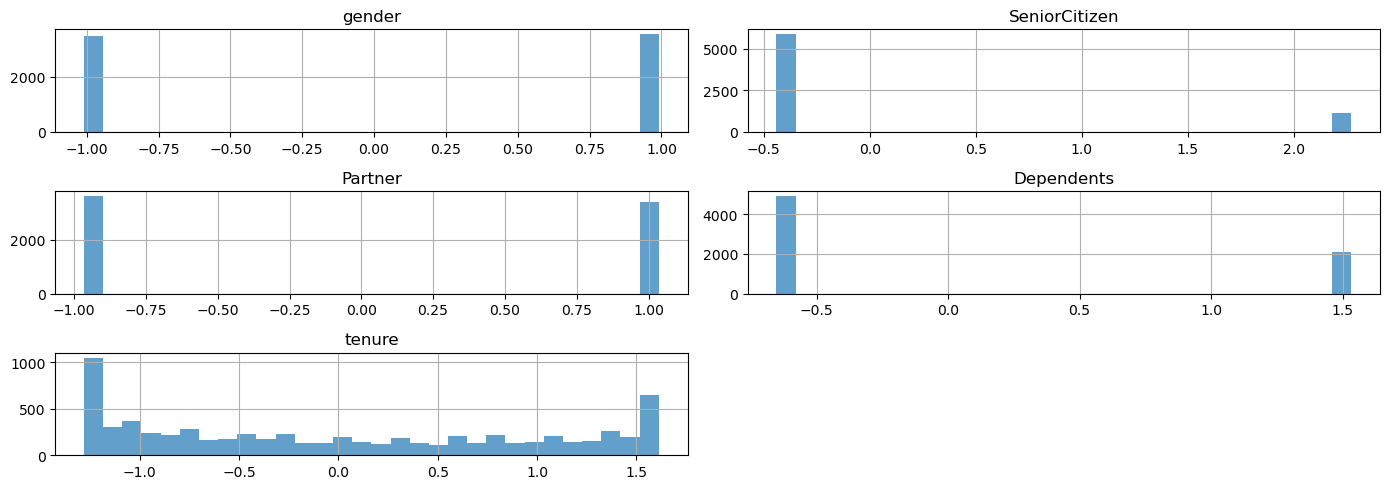


💡 INSIGHTS:
- Les features négatives sont corrélées négativement avec le churn
- Les features positives augmentent le risque de churn


In [21]:
# Comparaison avant/après encodage
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Corrélations avec le churn (après encodage)
correlations = df_encoded.corr()['Churn_Num'].sort_values(ascending=False)
top_features = correlations.head(10)

axes[0].barh(range(len(top_features)), top_features.values)
axes[0].set_yticks(range(len(top_features)))
axes[0].set_yticklabels(top_features.index)
axes[0].set_xlabel('Corrélation avec Churn')
axes[0].set_title('Top 10 Features corrélées au Churn')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# Distribution des features scalées
sample_features = X_scaled_df.iloc[:, :5]
sample_features.hist(ax=axes[1], bins=30, alpha=0.7)
axes[1].set_title('Distribution des features après scaling')
axes[1].set_xlabel('Valeur standardisée')

plt.tight_layout()
plt.show()

print("\n💡 INSIGHTS:")
print("- Les features négatives sont corrélées négativement avec le churn")
print("- Les features positives augmentent le risque de churn")

In [23]:
import os
import pickle

# Créer les dossiers
os.makedirs('data/encoded', exist_ok=True)
os.makedirs('models', exist_ok=True)

# 1. Sauvegarder X et y
np.save('data/encoded/X_scaled.npy', X_scaled)
np.save('data/encoded/y.npy', y.values)

# 2. Sauvegarder les DataFrames
X_scaled_df.to_csv('data/encoded/X_scaled.csv', index=False)
df_encoded.to_csv('data/encoded/telco_encoded_complete.csv', index=False)

# 3. Sauvegarder le scaler pour plus tard (déploiement)
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# 4. Sauvegarder les noms des colonnes
with open('models/feature_names.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

print("\n" + "="*60)
print("💾 FICHIERS SAUVEGARDÉS")
print("="*60)
print("📁 data/encoded/X_scaled.npy - Features normalisées")
print("📁 data/encoded/y.npy - Target")
print("📁 data/encoded/X_scaled.csv - Features (CSV)")
print("📁 data/encoded/telco_encoded_complete.csv - Dataset complet encodé")
print("📁 models/scaler.pkl - StandardScaler pour déploiement")
print("📁 models/feature_names.pkl - Noms des colonnes")

print(f"\n📊 Statistiques finales:")
print(f"   • Nombre de features: {X_scaled.shape[1]}")
print(f"   • Nombre d'échantillons: {X_scaled.shape[0]}")
print(f"   • Taux de churn: {y.mean()*100:.1f}%")


💾 FICHIERS SAUVEGARDÉS
📁 data/encoded/X_scaled.npy - Features normalisées
📁 data/encoded/y.npy - Target
📁 data/encoded/X_scaled.csv - Features (CSV)
📁 data/encoded/telco_encoded_complete.csv - Dataset complet encodé
📁 models/scaler.pkl - StandardScaler pour déploiement
📁 models/feature_names.pkl - Noms des colonnes

📊 Statistiques finales:
   • Nombre de features: 37
   • Nombre d'échantillons: 7032
   • Taux de churn: 26.6%


In [27]:
# Test rapide pour vérifier que tout est prêt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

print("\n" + "="*60)
print("🧪 TEST RAPIDE - Vérification que tout fonctionne")
print("="*60)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Modèle basique
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# Score
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f"\n✅ Logistic Regression:")
print(f"   Train accuracy: {train_score:.3f}")
print(f"   Test accuracy: {test_score:.3f}")
print(f"   Différence: {(train_score - test_score):.3f}")

if abs(train_score - test_score) < 0.05:
    print("✅ Pas de sur-apprentissage majeur - Prêt pour le ML!")
else:
    print("⚠️ Léger surapprentissage - À surveiller")


🧪 TEST RAPIDE - Vérification que tout fonctionne

✅ Logistic Regression:
   Train accuracy: 0.808
   Test accuracy: 0.797
   Différence: 0.012
✅ Pas de sur-apprentissage majeur - Prêt pour le ML!


In [29]:
summary = pd.DataFrame({
    'Étape': ['Dataset original', 'Après nettoyage', 'Après encoding', 'Après scaling'],
    'Dimensions': [df.shape, df.shape, df_encoded.shape, X_scaled.shape],
    'Colonnes numériques': [
        df.select_dtypes(include=[np.number]).shape[1],
        df.select_dtypes(include=[np.number]).shape[1],
        df_encoded.select_dtypes(include=[np.number]).shape[1],
        X_scaled.shape[1]
    ]
})

print("\n" + "="*60)
print("📈 RÉSUMÉ DES TRANSFORMATIONS")
print("="*60)
print(summary.to_string(index=False))


📈 RÉSUMÉ DES TRANSFORMATIONS
           Étape Dimensions  Colonnes numériques
Dataset original (7032, 38)                   15
 Après nettoyage (7032, 38)                   15
  Après encoding (7032, 38)                   28
   Après scaling (7032, 37)                   37
